# Exploration of data

In [ ]:
import numpy as np
from pathlib import Path

data_dir = Path("../data")
first_file = sorted((data_dir / "Train" / "0").glob("*.npy"))[0]
print(f"Loading: {first_file.name}")

sample = np.load(first_file)
print(f"Single sample shape: {sample.shape}")
print(f"Dtype: {sample.dtype}")
print(f"Min: {sample.min():.4f}, Max: {sample.max():.4f}, Mean: {sample.mean():.4f}")

Loading: 0100.npy
Single sample shape: (128, 128, 125)
Dtype: uint16
Min: 45.0000, Max: 4365.0000, Mean: 1222.1913


In [8]:
# Count samples per class in Train and evaluation
for split in ["Train", "evaluation"]:
    print(f"\n=== {split} ===")
    split_dir = data_dir / split
    total = 0
    class_counts = {}
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*.npy")))
            class_counts[class_dir.name] = count
            total += count
            print(f"  Class {class_dir.name}: {count} samples")
    print(f"  TOTAL: {total} samples")


=== Train ===
  Class 0: 202 samples
  Class 1: 218 samples
  Class 2: 209 samples
  Class 3: 221 samples
  Class 4: 177 samples
  Class 5: 221 samples
  Class 6: 227 samples
  Class 7: 206 samples
  Class 8: 197 samples
  Class 9: 211 samples
  TOTAL: 2089 samples

=== evaluation ===
  Class 0: 50 samples
  Class 1: 50 samples
  Class 2: 50 samples
  Class 3: 50 samples
  Class 4: 50 samples
  Class 5: 50 samples
  Class 6: 50 samples
  Class 7: 50 samples
  Class 8: 50 samples
  Class 9: 50 samples
  TOTAL: 500 samples


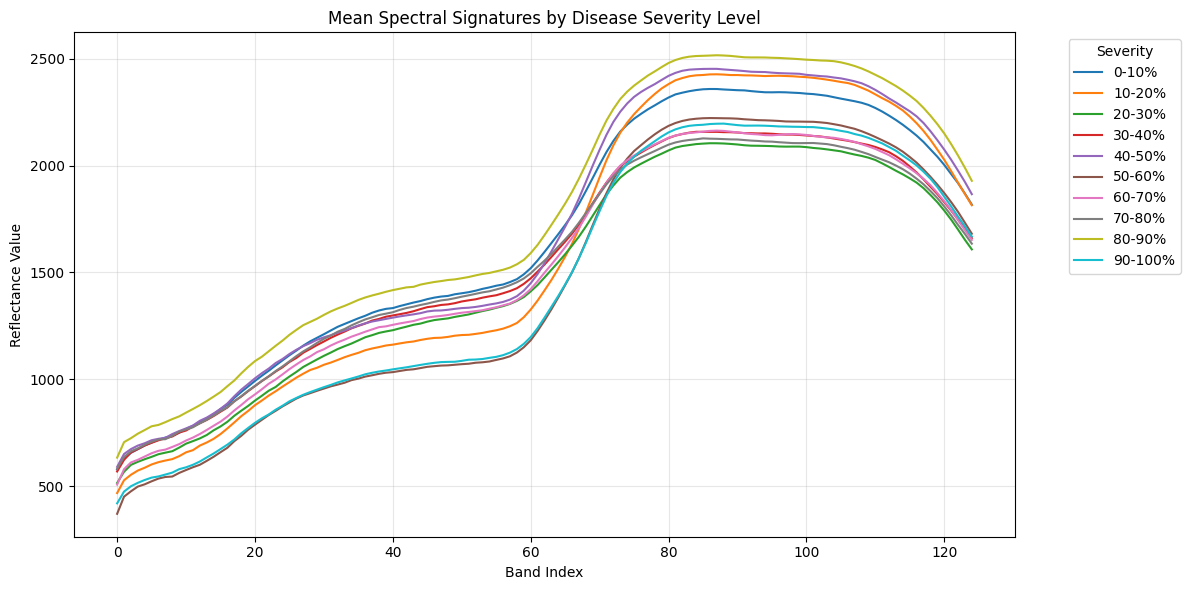

In [14]:
# Updated understanding: classes are disease severity levels
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("../data")

severity_labels = [
    "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
]

# Re-plot spectral signatures with correct labels
plt.figure(figsize=(12, 6))

for class_id in range(10):
    class_dir = data_dir / "Train" / str(class_id)
    files = sorted(class_dir.glob("*.npy"))
    
    spectra = []
    for f in files[:20]:
        img = np.load(f).astype(np.float32)
        spectra.append(img.mean(axis=(0, 1)))
    
    mean_spectrum = np.mean(spectra, axis=0)
    plt.plot(mean_spectrum, label=severity_labels[class_id], linewidth=1.5)

plt.xlabel("Band Index")
plt.ylabel("Reflectance Value")
plt.title("Mean Spectral Signatures by Disease Severity Level")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Severity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/spectral_by_severity.png", dpi=150, bbox_inches='tight')
plt.show()

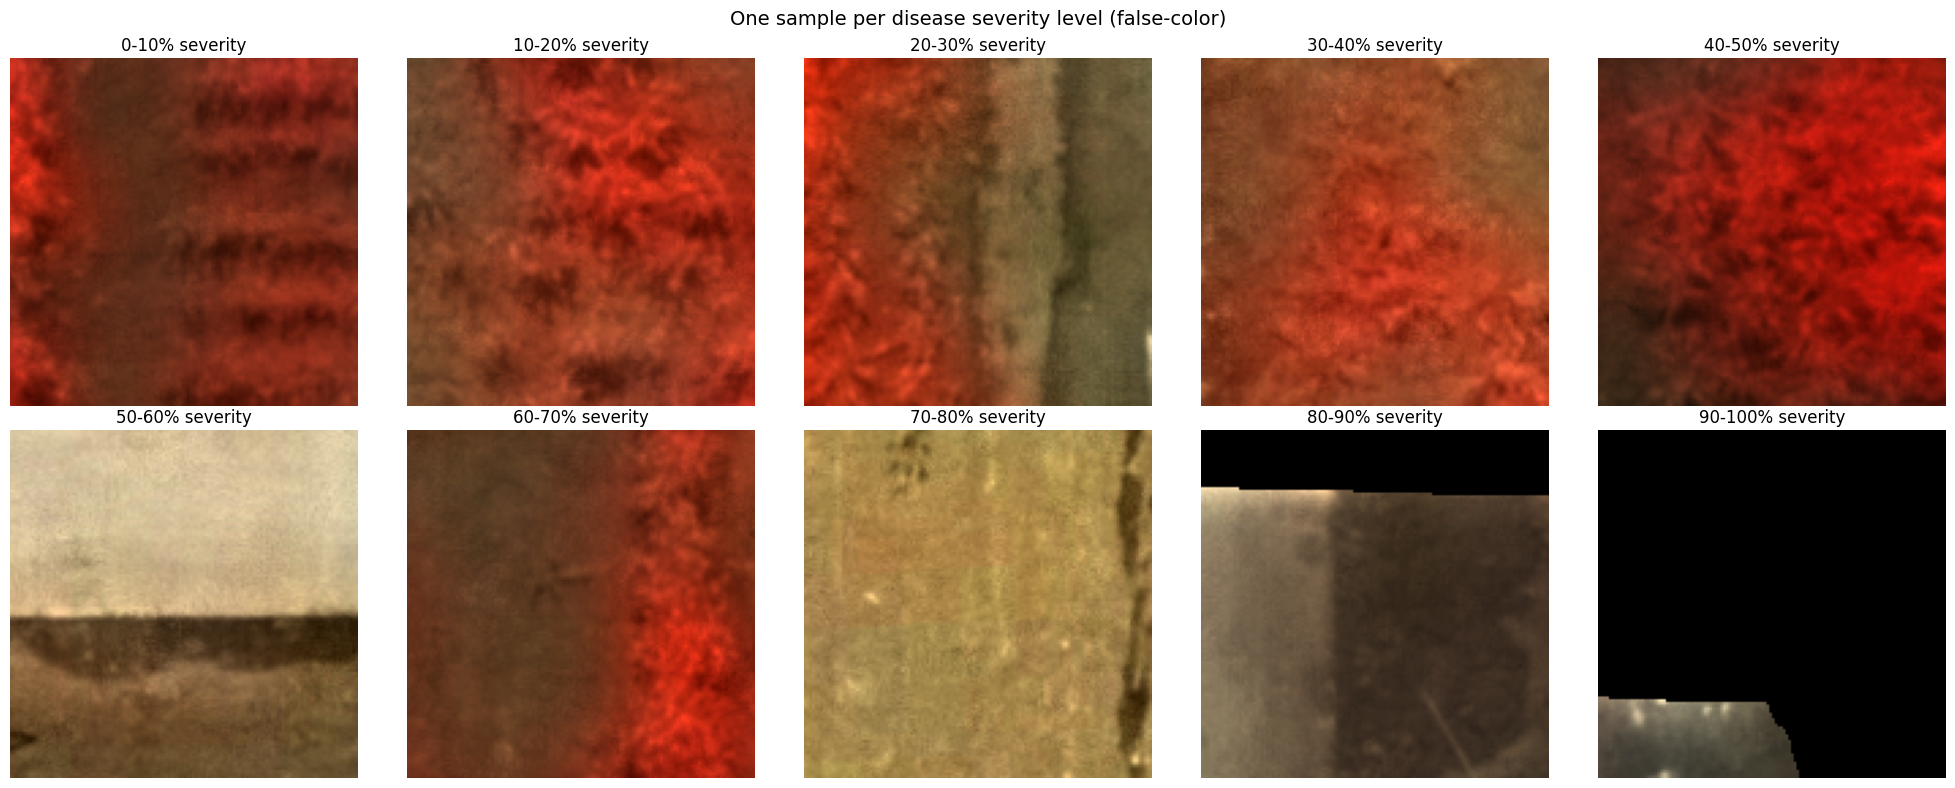

In [15]:
# Re-visualize with severity labels
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, class_id in enumerate(range(10)):
    ax = axes[i // 5, i % 5]
    class_dir = data_dir / "Train" / str(class_id)
    files = sorted(class_dir.glob("*.npy"))
    
    img = np.load(files[0]).astype(np.float32)
    h, w, bands = img.shape
    r, g, b = bands * 3 // 4, bands // 2, bands // 4
    rgb = img[:, :, [r, g, b]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    ax.imshow(rgb)
    ax.set_title(f"{severity_labels[class_id]} severity")
    ax.axis("off")

plt.suptitle("One sample per disease severity level (false-color)", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/severity_samples_overview.png", dpi=150, bbox_inches='tight')
plt.show()